In [1]:
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, set_seed
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

DATA_PATH = 'data/tweetsEsquerdaDireita.csv'
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
EPOCHS = 3
BATCH_SIZE = 8
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)


/home/joaolima/Projetos/analise-vies-politico/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


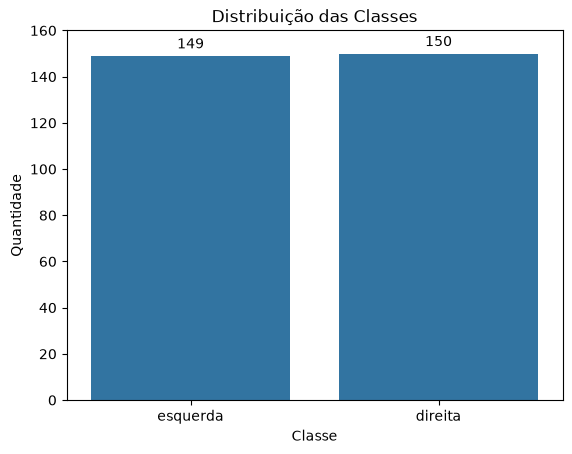

In [2]:
df = pd.read_csv(DATA_PATH)
label_map = {'esquerda': 0, 'direita': 1}
id2label = {0: 'esquerda', 1: 'direita'}
df['label'] = df['rotulo'].map(label_map)

ax = sns.countplot(x='rotulo', data=df)
plt.ylim(0, 160)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()


In [3]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['texto'].to_numpy(), df['label'].to_numpy(), test_size=0.2, random_state=SEED, stratify=df['label'].to_numpy()
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

train_dataset = TweetDataset(train_texts, train_labels, tokenizer)
val_dataset = TweetDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()
for epoch in range(EPOCHS):
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()


Loading weights:   0%|                                 | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████| 199/199 [00:00<00:00, 37283.53it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

              precision    recall  f1-score   support

    esquerda       0.85      0.97      0.91        30
     direita       0.96      0.83      0.89        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60



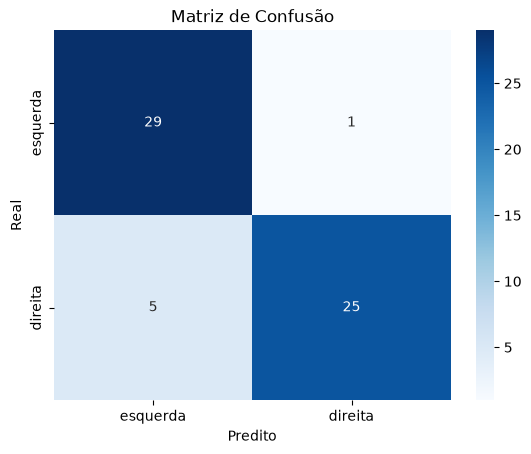

In [5]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(classification_report(true_labels, predictions, target_names=['esquerda', 'direita']))

cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['esquerda', 'direita'], yticklabels=['esquerda', 'direita'])
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


In [6]:
def analisar_vies(texto):
    model.eval()
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()
    return id2label[pred_class], confidence

frases_teste = [
    'A privatização de empresas estatais é a melhor saída para reduzir o inchaço da máquina pública e atrair investimentos.',
    'Garantir saúde pública universal e gratuita é um dever inegociável do Estado perante a população.',
    'O livre mercado e a desregulamentação da economia são vitais para impulsionar o empreendedorismo e o crescimento.',
    'É fundamental expandir os programas sociais de transferência de renda para mitigar a extrema pobreza no país.',
    'A redução da carga tributária sobre o setor produtivo estimula a competitividade e a geração de empregos.',
    'Fortalecer a previdência pública e garantir direitos trabalhistas são pilares essenciais para a proteção dos trabalhadores.',
    'A concessão de serviços de saneamento básico à iniciativa privada moderniza a infraestrutura nacional.',
    'A valorização dos serviços públicos essenciais deve priorizar a igualdade de oportunidades para as classes vulneráveis.'
]

for frase in frases_teste:
    label, conf = analisar_vies(frase)
    print('Texto:', frase)
    print('Resultado:', label, '| Confiança:', f'{conf:.2%}')
    print()


Texto: A privatização de empresas estatais é a melhor saída para reduzir o inchaço da máquina pública e atrair investimentos.
Resultado: direita | Confiança: 86.14%

Texto: Garantir saúde pública universal e gratuita é um dever inegociável do Estado perante a população.
Resultado: direita | Confiança: 88.26%

Texto: O livre mercado e a desregulamentação da economia são vitais para impulsionar o empreendedorismo e o crescimento.
Resultado: direita | Confiança: 97.94%

Texto: É fundamental expandir os programas sociais de transferência de renda para mitigar a extrema pobreza no país.
Resultado: direita | Confiança: 60.41%

Texto: A redução da carga tributária sobre o setor produtivo estimula a competitividade e a geração de empregos.
Resultado: direita | Confiança: 77.23%

Texto: Fortalecer a previdência pública e garantir direitos trabalhistas são pilares essenciais para a proteção dos trabalhadores.
Resultado: esquerda | Confiança: 91.06%

Texto: A concessão de serviços de saneamento b